In [2]:
import sys
print(sys.executable)

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Scripts\python.exe


### Libraries

In [3]:
import importlib.util

required = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "torch": "torch>=2.1",
    "sklearn": "scikit-learn>=1.3",
    "pyarrow": "pyarrow>=12",
    "tqdm": "tqdm>=4.65",
}

missing = [
    package
    for module, package in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Missing packages: " + ", ".join(missing))
    print("Install them with: uv pip install " + " ".join(missing))

print("Environment ready")

Environment ready


In [4]:
import itertools
import json
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from models.DLinearFull import DLinearFull

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DLinearFull)
device

<class 'models.DLinearFull.DLinearFull'>


device(type='cpu')

# Full zero-aware DLinear
- past `log_sales` base DLinear
- past numerical covariates
- static category, department, and state embeddings
- separate non-zero occurrence and positive-magnitude outputs

In [5]:
FEATURE_PATH = PROJECT_ROOT / "data/m5/processed/m5_long_features.parquet"
BASE_SPLIT_PATH = (
    PROJECT_ROOT / "data/m5/processed/splits/combined_exclusive_series.csv"
)

RESULT_DIR = PROJECT_ROOT / "notebooks/Results/dlinear_full_model_no_future_covariates"
CHECKPOINT_DIR = RESULT_DIR / "checkpoints"
PREDICTION_DIR = RESULT_DIR / "predictions"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

### Prepare the grid and final evaluation periods

In [6]:
PRED_LEN = 28
BATCH_SIZE = 64
EVAL_BATCH_SIZE = 1024
RANDOM_SEED = 42
FINAL_SEEDS = [42, 123, 2025]

# M5 time_idx is zero-based: time_idx 0 is d_1
SEARCH_TRAIN_END_IDX = 1856       # d_1857
VALIDATION_START_IDX = 1857       # d_1858
VALIDATION_END_IDX = 1884         # d_1885
TEST_START_IDX = 1885             # d_1886
TEST_END_IDX = 1912               # d_1913

CONVERGENCE_MIN_DELTA = 1e-5

# 0 use allseries
MAX_TRAIN_SERIES_PER_GROUP = 0
MAX_EVAL_SERIES_PER_GROUP = 0

OCCURRENCE_LOSS_WEIGHT = 1.0
MAGNITUDE_LOSS_WEIGHT = 1.0
NONZERO_PROBABILITY_THRESHOLD = 0.5

GRID = {
    "seq_len": [28, 56, 112],
    "learning_rate": [1e-3, 3e-4],
    "epochs": [50],
    "samples_per_epoch": [10_000, 20_000, 40_000],
    "embedding_dim": [4],
}

TRAIN_GROUPS = ["normal", "intermittent"]
EVAL_GROUPS = [
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
    "all_combined",
]

MODEL_NAME = "global_dlinear_full"

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

In [8]:
TARGET_COLUMN = "log_sales"

# Past numerical covariates
PAST_COVARIATE_COLUMNS = [
    "day_of_week",
    "is_weekend",
    "event_flag",
    "snap_flag",
    "sell_price",
]

STATIC_METADATA_COLUMNS = [
    "cat_id",
    "dept_id",
    "state_id",
]

ALL_COVARIATE_COLUMNS = PAST_COVARIATE_COLUMNS.copy()
PAST_COVARIATE_INDICES = list(range(len(PAST_COVARIATE_COLUMNS)))
N_PAST_COVARIATES = len(PAST_COVARIATE_COLUMNS)

print("Past covariates:", PAST_COVARIATE_COLUMNS)
print("Static metadata:", STATIC_METADATA_COLUMNS)

Past covariates: ['day_of_week', 'is_weekend', 'event_flag', 'snap_flag', 'sell_price']
Static metadata: ['cat_id', 'dept_id', 'state_id']


### Read data and create subsets

In [9]:
def sample_ids(series_ids, max_count, seed):
    series_ids = list(series_ids)

    if max_count is None or max_count <= 0 or max_count >= len(series_ids):
        return series_ids

    return (
        pd.Series(series_ids)
        .sample(n=max_count, random_state=seed)
        .astype(int)
        .tolist()
    )

In [10]:
series_table = pd.read_csv(BASE_SPLIT_PATH)

split_ids = {}

for split_name in ["normal", "intermittent", "cold_start_item", "cold_start_store"]:
    ids = (
        series_table[series_table["exclusive_split"] == split_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )
    split_ids[split_name] = sample_ids(
        ids,
        MAX_EVAL_SERIES_PER_GROUP,
        RANDOM_SEED,
    )

split_ids["all_combined"] = (
    split_ids["normal"]
    + split_ids["intermittent"]
    + split_ids["cold_start_item"]
    + split_ids["cold_start_store"]
)

train_ids = []

for group_name in TRAIN_GROUPS:
    group_ids = (
        series_table[series_table["exclusive_split"] == group_name]["series_idx"]
        .dropna()
        .astype(int)
        .tolist()
    )
    train_ids.extend(
        sample_ids(
            group_ids,
            MAX_TRAIN_SERIES_PER_GROUP,
            RANDOM_SEED,
        )
    )

print("Intermittent labels: existing split based on all 1,913 days")
print("Train groups:", TRAIN_GROUPS)
print("Train series:", len(train_ids))

for split_name, ids in split_ids.items():
    print(split_name, len(ids))

assert len(split_ids["all_combined"]) == series_table["series_idx"].nunique()
assert len(split_ids["all_combined"]) == len(set(split_ids["all_combined"]))

Intermittent labels: existing split based on all 1,913 days
Train groups: ['normal', 'intermittent']
Train series: 24696
normal 7600
intermittent 17096
cold_start_item 3050
cold_start_store 2744
all_combined 30490


#### Scale numerical covariates

In [ ]:
def fit_covariate_scaler(series_ids, fit_end_idx):
    scaler_df = pd.read_parquet(
        FEATURE_PATH,
        columns=[
            "series_idx",
            "time_idx",
            "price_missing_flag",
        ] + ALL_COVARIATE_COLUMNS,
        filters=[
            ("series_idx", "in", list(series_ids)),
            ("time_idx", "<=", fit_end_idx),
        ],
    )
    scaler_df = scaler_df.sort_values(["series_idx", "time_idx"])

    original_price = scaler_df["sell_price"].mask(
        scaler_df["price_missing_flag"].astype(bool)
    )
    price_fallback = float(original_price.dropna().median())

    scaler_df["sell_price"] = (
        original_price
        .groupby(scaler_df["series_idx"])
        .ffill()
        .fillna(price_fallback)
    )

    covariates = (
        scaler_df[ALL_COVARIATE_COLUMNS]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .to_numpy(dtype=np.float32)
    )

    scaler = RobustScaler()
    scaler.fit(covariates)

    return scaler, price_fallback

#### Encode static metadata

In [12]:
def fit_metadata_encoders(series_table, series_ids):
    # Encoders see training entities only
    # index 0 is for unknown values
    metadata_df = series_table[
        series_table["series_idx"].isin(series_ids)
    ][STATIC_METADATA_COLUMNS]

    encoders = {}
    cardinalities = []

    for column in STATIC_METADATA_COLUMNS:
        known_values = sorted(
            metadata_df[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        encoders[column] = {
            value: encoded_value
            for encoded_value, value in enumerate(known_values, start=1)
        }
        cardinalities.append(len(known_values) + 1)

    return encoders, cardinalities

#### Load one array per series

In [ ]:
def load_series_arrays(
    series_ids,
    covariate_scaler,
    price_fallback,
    metadata_encoders,
    required_end_idx,
):
    read_columns = list(dict.fromkeys(
        [
            "series_idx",
            "time_idx",
            "sales",
            TARGET_COLUMN,
            "price_missing_flag",
        ] + ALL_COVARIATE_COLUMNS
    ))

    df = pd.read_parquet(
        FEATURE_PATH,
        columns=read_columns,
        filters=[("series_idx", "in", list(series_ids))],
    )
    df = df.sort_values(["series_idx", "time_idx"]).reset_index(drop=True)

    metadata_lookup = series_table.set_index("series_idx")

    past_arrays = []
    sales_arrays = []
    metadata_arrays = []
    clean_ids = []

    for series_idx, group in df.groupby("series_idx", sort=True):
        group = group.sort_values("time_idx").copy()

        observed_price = group["sell_price"].mask(
            group["price_missing_flag"].astype(bool)
        )
        group["sell_price"] = observed_price.ffill().fillna(price_fallback)

        covariate_values = (
            group[ALL_COVARIATE_COLUMNS]
            .replace([np.inf, -np.inf], 0)
            .fillna(0)
            .to_numpy(dtype=np.float32)
        )
        covariate_values = covariate_scaler.transform(
            covariate_values
        ).astype(np.float32)

        log_sales = group[[TARGET_COLUMN]].to_numpy(dtype=np.float32)
        sales = group["sales"].to_numpy(dtype=np.float32)

        past_covariates = covariate_values[:, PAST_COVARIATE_INDICES]
        past_values = np.concatenate([log_sales, past_covariates], axis=1)

        row = metadata_lookup.loc[int(series_idx)]
        metadata = np.array([
            metadata_encoders[column].get(str(row[column]), 0)
            for column in STATIC_METADATA_COLUMNS
        ], dtype=np.int64)

        has_required_length = len(group) > required_end_idx
        has_finite_values = (
            np.isfinite(past_values).all()
            and np.isfinite(sales).all()
        )

        if has_required_length and has_finite_values:
            past_arrays.append(past_values.copy())
            sales_arrays.append(sales.copy())
            metadata_arrays.append(metadata)
            clean_ids.append(int(series_idx))

    return {
        "past_arrays": past_arrays,
        "sales_arrays": sales_arrays,
        "metadata_arrays": metadata_arrays,
        "series_ids": clean_ids,
    }




In [14]:
def select_loaded_series(loaded_data, selected_ids):
    position_by_id = {
        series_idx: position
        for position, series_idx in enumerate(loaded_data["series_ids"])
    }
    positions = [
        position_by_id[series_idx]
        for series_idx in selected_ids
        if series_idx in position_by_id
    ]

    return {
        "past_arrays": [loaded_data["past_arrays"][i] for i in positions],
        "sales_arrays": [loaded_data["sales_arrays"][i] for i in positions],
        "metadata_arrays": [loaded_data["metadata_arrays"][i] for i in positions],
        "series_ids": [loaded_data["series_ids"][i] for i in positions],
    }

### Windowing class for deterministic global training

In [15]:
class RandomWindowDataset(Dataset):
    def __init__(
        self,
        loaded_data,
        seq_len,
        pred_len,
        training_end_exclusive,
        samples_per_epoch,
        seed=42,
    ):
        self.past_arrays = loaded_data["past_arrays"]
        self.metadata_arrays = loaded_data["metadata_arrays"]
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.training_end_exclusive = training_end_exclusive
        self.samples_per_epoch = samples_per_epoch
        self.seed = seed
        self.epoch = 0

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return self.samples_per_epoch

    def __getitem__(self, index):
        # Choose one time series
        sample_seed = self.seed + self.epoch * self.samples_per_epoch + index
        rng = np.random.default_rng(sample_seed)

        series_position = rng.integers(0, len(self.past_arrays))
        past_values = self.past_arrays[series_position]

        max_start = (
            self.training_end_exclusive
            - self.seq_len
            - self.pred_len
        )
        start = rng.integers(0, max_start + 1)

        target_start = start + self.seq_len
        target_end = target_start + self.pred_len

        x_past = past_values[start:target_start].copy()
        y_log = past_values[target_start:target_end, 0:1].copy()
        metadata = self.metadata_arrays[series_position].copy()

        return (
            torch.from_numpy(x_past),
            torch.from_numpy(y_log),
            torch.from_numpy(metadata),
        )

### Validation and test tensor preparation

In [16]:
def build_forecast_data(loaded_data, seq_len, forecast_start_idx, pred_len):
    x_past_values = []
    metadata_values = []
    actual_sales_values = []
    seasonal_naive_values = []
    clean_ids = []

    forecast_end_idx = forecast_start_idx + pred_len

    for past_values, sales, metadata, series_idx in zip(
        loaded_data["past_arrays"],
        loaded_data["sales_arrays"],
        loaded_data["metadata_arrays"],
        loaded_data["series_ids"],
    ):
        if len(sales) < forecast_end_idx:
            continue

        x_past_values.append(
            past_values[forecast_start_idx - seq_len:forecast_start_idx]
        )
        metadata_values.append(metadata)
        actual_sales_values.append(sales[forecast_start_idx:forecast_end_idx])
        seasonal_naive_values.append(
            sales[forecast_start_idx - pred_len:forecast_start_idx]
        )
        clean_ids.append(series_idx)

    return {
        "x_past": np.stack(x_past_values).astype(np.float32),
        "metadata": np.stack(metadata_values).astype(np.int64),
        "actual_sales": np.stack(actual_sales_values).astype(np.float32),
        "seasonal_naive": np.stack(seasonal_naive_values).astype(np.float32),
        "series_ids": np.array(clean_ids, dtype=np.int64),
        "forecast_start_idx": forecast_start_idx,
    }

### Evaluation metrics and baselines

In [ ]:
def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return numerator / denominator


def calculate_metrics(predicted_sales, actual_sales, predicted_zero=None):
    predicted_sales = np.asarray(predicted_sales)
    actual_sales = np.asarray(actual_sales)

    if predicted_zero is None:
        predicted_zero = predicted_sales < 0.5

    actual_zero = actual_sales == 0
    predicted_zero = np.asarray(predicted_zero, dtype=bool)

    absolute_error = np.abs(predicted_sales - actual_sales)
    squared_error = (predicted_sales - actual_sales) ** 2

    true_zero_predicted_zero = int(np.sum(actual_zero & predicted_zero))
    true_zero_predicted_nonzero = int(np.sum(actual_zero & ~predicted_zero))
    true_nonzero_predicted_zero = int(np.sum(~actual_zero & predicted_zero))
    true_nonzero_predicted_nonzero = int(np.sum(~actual_zero & ~predicted_zero))

    zero_precision = safe_divide(
        true_zero_predicted_zero,
        true_zero_predicted_zero + true_nonzero_predicted_zero,
    )
    zero_recall = safe_divide(
        true_zero_predicted_zero,
        true_zero_predicted_zero + true_zero_predicted_nonzero,
    )
    zero_f1 = safe_divide(
        2 * zero_precision * zero_recall,
        zero_precision + zero_recall,
    )

    nonzero_precision = safe_divide(
        true_nonzero_predicted_nonzero,
        true_nonzero_predicted_nonzero + true_zero_predicted_nonzero,
    )
    nonzero_recall = safe_divide(
        true_nonzero_predicted_nonzero,
        true_nonzero_predicted_nonzero + true_nonzero_predicted_zero,
    )
    nonzero_f1 = safe_divide(
        2 * nonzero_precision * nonzero_recall,
        nonzero_precision + nonzero_recall,
    )

    return {
        "mae": float(np.mean(absolute_error)),
        "rmse": float(np.sqrt(np.mean(squared_error))),
        "wape": float(safe_divide(absolute_error.sum(), np.abs(actual_sales).sum())),
        "zero_precision": float(zero_precision),
        "zero_recall": float(zero_recall),
        "zero_f1": float(zero_f1),
        "nonzero_precision": float(nonzero_precision),
        "nonzero_recall": float(nonzero_recall),
        "nonzero_f1": float(nonzero_f1),
        "balanced_accuracy": float(np.nanmean([zero_recall, nonzero_recall])),
        "true_zero_predicted_zero": true_zero_predicted_zero,
        "true_zero_predicted_nonzero": true_zero_predicted_nonzero,
        "true_nonzero_predicted_zero": true_nonzero_predicted_zero,
        "true_nonzero_predicted_nonzero": true_nonzero_predicted_nonzero,
        "number_of_series": int(actual_sales.shape[0]),
        "number_of_forecast_observations": int(actual_sales.size),
        "zero_ratio": float(np.mean(actual_zero)),
        "total_actual_demand": float(actual_sales.sum()),
        "total_predicted_demand": float(predicted_sales.sum()),
    }



In [18]:
def build_baseline_predictions(forecast_data):
    x_past = forecast_data["x_past"]
    actual_sales = forecast_data["actual_sales"]

    last_log_value = x_past[:, -1, 0:1]
    last_value = np.repeat(np.expm1(last_log_value), PRED_LEN, axis=1)

    return {
        "zero": np.zeros_like(actual_sales),
        "last_value": np.clip(last_value, 0, None),
        "seasonal_naive_28": forecast_data["seasonal_naive"],
    }

### Full model prediction

In [19]:
def predict_full_model(model, forecast_data):
    model.eval()

    predicted_sales_batches = []
    predicted_log_batches = []
    nonzero_probability_batches = []
    positive_magnitude_batches = []

    number_of_series = forecast_data["x_past"].shape[0]

    with torch.no_grad():
        for batch_start in range(0, number_of_series, EVAL_BATCH_SIZE):
            batch_end = min(batch_start + EVAL_BATCH_SIZE, number_of_series)

            x_past = torch.from_numpy(
                forecast_data["x_past"][batch_start:batch_end]
            ).to(device)
            metadata = torch.from_numpy(
                forecast_data["metadata"][batch_start:batch_end]
            ).long().to(device)

            occurrence_logits, positive_log_magnitude = model(
                x_past,
                metadata,
            )

            nonzero_probability = torch.sigmoid(occurrence_logits)
            positive_magnitude = torch.expm1(
                positive_log_magnitude
            ).clamp_min(0)
            
            predicted_sales = nonzero_probability * positive_magnitude

            predicted_sales_batches.append(
                predicted_sales.cpu().numpy().squeeze(-1)
            )
            predicted_log_batches.append(
                torch.log1p(predicted_sales).cpu().numpy().squeeze(-1)
            )
            nonzero_probability_batches.append(
                nonzero_probability.cpu().numpy().squeeze(-1)
            )
            positive_magnitude_batches.append(
                positive_magnitude.cpu().numpy().squeeze(-1)
            )

    predicted_sales = np.concatenate(predicted_sales_batches, axis=0)
    nonzero_probability = np.concatenate(
        nonzero_probability_batches,
        axis=0,
    )

    return {
        "predicted_sales": predicted_sales,
        "predicted_log_sales": np.concatenate(predicted_log_batches, axis=0),
        "nonzero_probability": nonzero_probability,
        "positive_magnitude": np.concatenate(
            positive_magnitude_batches,
            axis=0,
        ),
        "predicted_zero": (
            nonzero_probability < NONZERO_PROBABILITY_THRESHOLD
        ),
    }

### Training the global full model

In [20]:
def set_random_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_global_dlinear_full(
    train_data,
    metadata_cardinalities,
    seq_len,
    pred_len,
    learning_rate,
    epochs,
    samples_per_epoch,
    embedding_dim,
    training_end_exclusive,
    seed,
    validation_data=None,
):
    train_dataset = RandomWindowDataset(
        loaded_data=train_data,
        seq_len=seq_len,
        pred_len=pred_len,
        training_end_exclusive=training_end_exclusive,
        samples_per_epoch=samples_per_epoch,
        seed=seed,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    set_random_seed(seed)

    model = DLinearFull(
        seq_len=seq_len,
        pred_len=pred_len,
        n_past_covariates=N_PAST_COVARIATES,
        metadata_cardinalities=metadata_cardinalities,
        embedding_dim=embedding_dim,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    occurrence_loss_fn = torch.nn.BCEWithLogitsLoss()
    magnitude_loss_fn = torch.nn.MSELoss()

    best_validation_wape = float("inf")
    best_validation_metrics = None
    best_state = None
    best_epoch = None
    previous_train_loss = None
    first_converged_epoch = None
    optimizer_updates = 0
    history = []

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.perf_counter()
        train_dataset.set_epoch(epoch - 1)
        model.train()

        total_losses = []
        occurrence_losses = []
        magnitude_losses = []

        for x_past, y_log, metadata in tqdm(
            train_loader,
            desc=f"seq={seq_len}, lr={learning_rate}, epoch={epoch}",
        ):
            x_past = x_past.to(device)
            y_log = y_log.to(device)
            metadata = metadata.long().to(device)

            occurrence_target = (y_log > 0).float()
            positive_mask = occurrence_target.bool()

            optimizer.zero_grad()
            occurrence_logits, positive_log_magnitude = model(
                x_past,
                metadata,
            )

            occurrence_loss = occurrence_loss_fn(
                occurrence_logits,
                occurrence_target,
            )

            if positive_mask.any():
                magnitude_loss = magnitude_loss_fn(
                    positive_log_magnitude[positive_mask],
                    y_log[positive_mask],
                )
            else:
                magnitude_loss = positive_log_magnitude.sum() * 0.0

            total_loss = (
                OCCURRENCE_LOSS_WEIGHT * occurrence_loss
                + MAGNITUDE_LOSS_WEIGHT * magnitude_loss
            )

            total_loss.backward()
            optimizer.step()
            optimizer_updates += 1

            total_losses.append(total_loss.item())
            occurrence_losses.append(occurrence_loss.item())
            magnitude_losses.append(magnitude_loss.item())

        train_total_loss = float(np.mean(total_losses))
        train_occurrence_loss = float(np.mean(occurrence_losses))
        train_magnitude_loss = float(np.mean(magnitude_losses))

        loss_difference = np.nan
        if previous_train_loss is not None:
            loss_difference = abs(previous_train_loss - train_total_loss)
            if (
                first_converged_epoch is None
                and loss_difference < CONVERGENCE_MIN_DELTA
            ):
                first_converged_epoch = epoch

        checkpoint_saved = False
        validation_metrics = {}

        if validation_data is not None:
            validation_prediction = predict_full_model(model, validation_data)
            validation_metrics = calculate_metrics(
                validation_prediction["predicted_sales"],
                validation_data["actual_sales"],
                predicted_zero=validation_prediction["predicted_zero"],
            )

            if validation_metrics["wape"] < best_validation_wape:
                best_validation_wape = validation_metrics["wape"]
                best_validation_metrics = validation_metrics.copy()
                best_epoch = epoch
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in model.state_dict().items()
                }
                checkpoint_saved = True
        else:
            # Final refitting uses the epoch count chosen during validation.
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            checkpoint_saved = epoch == epochs

        history.append({
            "epoch": epoch,
            "optimizer_updates": optimizer_updates,
            "samples_seen": epoch * samples_per_epoch,
            "learning_rate": learning_rate,
            "training_total_loss": train_total_loss,
            "training_occurrence_bce": train_occurrence_loss,
            "training_magnitude_mse": train_magnitude_loss,
            "training_loss_difference": loss_difference,
            "validation_mae": validation_metrics.get("mae", np.nan),
            "validation_rmse": validation_metrics.get("rmse", np.nan),
            "validation_wape": validation_metrics.get("wape", np.nan),
            "epoch_runtime_seconds": time.perf_counter() - epoch_start_time,
            "checkpoint_saved": checkpoint_saved,
        })

        previous_train_loss = train_total_loss

    model.load_state_dict(best_state)

    return {
        "model": model,
        "best_epoch": best_epoch,
        "best_validation_metrics": best_validation_metrics,
        "first_converged_epoch": first_converged_epoch,
        "history": history,
        "parameter_count": sum(
            parameter.numel() for parameter in model.parameters()
        ),
    }

### Validation-only grid search

In [21]:
# Preprocessing is fitted only on training series and d_1 to d_1857.
search_scaler, search_price_fallback = fit_covariate_scaler(
    train_ids,
    SEARCH_TRAIN_END_IDX,
)
search_metadata_encoders, search_metadata_cardinalities = fit_metadata_encoders(
    series_table,
    train_ids,
)

with open(RESULT_DIR / "search_covariate_scaler.pkl", "wb") as file:
    pickle.dump(search_scaler, file)

with open(RESULT_DIR / "search_metadata_encoders.json", "w", encoding="utf-8") as file:
    json.dump(search_metadata_encoders, file, indent=2)

search_train_data = load_series_arrays(
    train_ids,
    search_scaler,
    search_price_fallback,
    search_metadata_encoders,
    VALIDATION_END_IDX,
)

print("Loaded training series:", len(search_train_data["series_ids"]))

Loaded training series: 24696


In [22]:
def make_run_id(prefix, seq_len, learning_rate, samples_per_epoch, seed):
    learning_rate_text = str(learning_rate).replace(".", "p").replace("-", "m")
    return (
        f"{prefix}_sl{seq_len}_lr{learning_rate_text}_"
        f"spe{samples_per_epoch}_seed{seed}"
    )


grid_combinations = list(itertools.product(
    GRID["seq_len"],
    GRID["learning_rate"],
    GRID["epochs"],
    GRID["samples_per_epoch"],
    GRID["embedding_dim"],
))

grid_results = []
search_history = []
validation_cache = {}

for seq_len, learning_rate, epochs, samples_per_epoch, embedding_dim in grid_combinations:
    run_id = make_run_id(
        "full_search",
        seq_len,
        learning_rate,
        samples_per_epoch,
        RANDOM_SEED,
    )

    print("\nGrid run:", run_id)

    if seq_len not in validation_cache:
        validation_cache[seq_len] = build_forecast_data(
            search_train_data,
            seq_len,
            VALIDATION_START_IDX,
            PRED_LEN,
        )

    training_result = train_global_dlinear_full(
        train_data=search_train_data,
        metadata_cardinalities=search_metadata_cardinalities,
        seq_len=seq_len,
        pred_len=PRED_LEN,
        learning_rate=learning_rate,
        epochs=epochs,
        samples_per_epoch=samples_per_epoch,
        embedding_dim=embedding_dim,
        training_end_exclusive=VALIDATION_START_IDX,
        seed=RANDOM_SEED,
        validation_data=validation_cache[seq_len],
    )

    model = training_result["model"]
    validation_metrics = training_result["best_validation_metrics"]

    checkpoint_path = CHECKPOINT_DIR / f"{run_id}.pt"
    torch.save({
        "run_id": run_id,
        "model_state_dict": model.state_dict(),
        "seq_len": seq_len,
        "pred_len": PRED_LEN,
        "learning_rate": learning_rate,
        "samples_per_epoch": samples_per_epoch,
        "embedding_dim": embedding_dim,
        "best_epoch": training_result["best_epoch"],
        "metadata_cardinalities": search_metadata_cardinalities,
        "future_covariates_used": [],
    }, checkpoint_path)

    grid_results.append({
        "run_id": run_id,
        "model_name": MODEL_NAME,
        "sequence_length": seq_len,
        "forecast_horizon": PRED_LEN,
        "learning_rate": learning_rate,
        "batch_size": BATCH_SIZE,
        "samples_per_epoch": samples_per_epoch,
        "maximum_epochs": epochs,
        "epochs_completed": len(training_result["history"]),
        "best_epoch": training_result["best_epoch"],
        "first_converged_epoch": training_result["first_converged_epoch"],
        "embedding_dimension": embedding_dim,
        "number_of_training_series": len(search_train_data["series_ids"]),
        "model_parameter_count": training_result["parameter_count"],
        "checkpoint_path": str(checkpoint_path),
        "validation_mae": validation_metrics["mae"],
        "validation_rmse": validation_metrics["rmse"],
        "validation_wape": validation_metrics["wape"],
        "validation_zero_f1": validation_metrics["zero_f1"],
    })

    for history_row in training_result["history"]:
        search_history.append({
            "run_id": run_id,
            "phase": "hyperparameter_search",
            **history_row,
        })

    # Save after every run so a stopped notebook keeps completed results.
    pd.DataFrame(grid_results).to_csv(
        RESULT_DIR / "full_model_grid_validation_results.csv",
        index=False,
    )
    pd.DataFrame(search_history).to_csv(
        RESULT_DIR / "full_model_training_history.csv",
        index=False,
    )

grid_results_df = pd.DataFrame(grid_results)
grid_results_df


Grid run: full_search_sl28_lr0p001_spe10000_seed42


seq=28, lr=0.001, epoch=50: 100%|██████████| 157/157 [00:00<00:00, 239.02it/s]



Grid run: full_search_sl28_lr0p001_spe20000_seed42


seq=28, lr=0.001, epoch=50: 100%|██████████| 313/313 [00:01<00:00, 261.22it/s]



Grid run: full_search_sl28_lr0p001_spe40000_seed42


...


Grid run: full_search_sl112_lr0p0003_spe20000_seed42


seq=112, lr=0.0003, epoch=50: 100%|██████████| 313/313 [00:01<00:00, 233.98it/s]



Grid run: full_search_sl112_lr0p0003_spe40000_seed42


seq=112, lr=0.0003, epoch=50: 100%|██████████| 625/625 [00:02<00:00, 211.19it/s]


,run_id,model_name,sequence_length,forecast_horizon,learning_rate,batch_size,samples_per_epoch,maximum_epochs,epochs_completed,best_epoch,first_converged_epoch,embedding_dimension,number_of_training_series,model_parameter_count,checkpoint_path,validation_mae,validation_rmse,validation_wape,validation_zero_f1
0,full_search_sl28_lr0p001_spe10000_seed42,global_dlinear_full,28,28,0.0010,64,10000,50,50,11,NaN,4,24696,11068,c:\Users\Francisco\Documents\Documentos-secund...,0.988727,2.352448,0.737674,0.793101
1,full_search_sl28_lr0p001_spe20000_seed42,global_dlinear_full,28,28,0.0010,64,20000,50,50,47,NaN,4,24696,11068,c:\Users\Francisco\Documents\Documentos-secund...,0.989644,2.269880,0.738358,0.793698
2,full_search_sl28_lr0p001_spe40000_seed42,global_dlinear_full,28,28,0.0010,64,40000,50,50,49,28.0,4,24696,11068,c:\Users\Francisco\Documents\Documentos-secund...,0.990288,2.336981,0.738839,0.793502
3,full_search_sl28_lr0p0003_spe10000_seed42,global_dlinear_full,28,28,0.0003,64,10000,50,50,31,NaN,4,24696,11068,c:\Users\Francisco\Documents\Documentos-secund...,0.984251,2.325460,0.734334,0.794491
4,full_search_sl28_lr0p0003_spe20000_seed42,global_dlinear_full,28,28,0.0003,64,20000,50,50,12,NaN,4,24696,11068,c:\Users\Francisco\Documents\Documentos-secund...,0.984394,2.294661,0.734440,0.793969
5,full_search_sl28_lr0p0003_spe40000_seed42,global_dlinear_full,28,28,0.0003,64,40000,50,50,6,NaN,4,24696,11068,c:\Users\Francisco\Documents\Documentos-secund...,0.984682,2.293944,0.734655,0.793952
6,full_search_sl56_lr0p001_spe10000_seed42,global_dlinear_full,56,28,0.0010,64,10000,50,50,6,NaN,4,24696,21260,c:\Users\Francisco\Documents\Documentos-secund...,0.992445,2.384776,0.740448,0.794102
7,full_search_sl56_lr0p001_spe20000_seed42,global_dlinear_full,56,28,0.0010,64,20000,50,50,3,NaN,4,24696,21260,c:\Users\Francisco\Documents\Documentos-secund...,0.991799,2.377136,0.739965,0.794082
8,full_search_sl56_lr0p001_spe40000_seed42,global_dlinear_full,56,28,0.0010,64,40000,50,50,3,49.0,4,24696,21260,c:\Users\Francisco\Documents\Documentos-secund...,0.994125,2.363656,0.741701,0.794123
9,full_search_sl56_lr0p0003_spe10000_seed42,global_dlinear_full,56,28,0.0003,64,10000,50,50,22,NaN,4,24696,21260,c:\Users\Francisco\Documents\Documentos-secund...,0.988643,2.293377,0.737611,0.794445


### Select one configuration before testing

In [23]:
# One configuration is selected for the model, not one per test subset.
selected_row = (
    grid_results_df
    .sort_values([
        "validation_wape",
        "validation_rmse",
        "model_parameter_count",
    ])
    .iloc[0]
)

selected_config = {
    "selected_run_id": selected_row["run_id"],
    "seq_len": int(selected_row["sequence_length"]),
    "pred_len": int(selected_row["forecast_horizon"]),
    "learning_rate": float(selected_row["learning_rate"]),
    "samples_per_epoch": int(selected_row["samples_per_epoch"]),
    "embedding_dim": int(selected_row["embedding_dimension"]),
    "refit_epochs": int(selected_row["best_epoch"]),
    "selection_metric": "aggregate validation WAPE on normal + intermittent series",
    "future_covariates_used": [],
}

with open(RESULT_DIR / "selected_configuration.json", "w", encoding="utf-8") as file:
    json.dump(selected_config, file, indent=2)

selected_config

{'selected_run_id': 'full_search_sl28_lr0p0003_spe10000_seed42',
 'seq_len': 28,
 'pred_len': 28,
 'learning_rate': 0.0003,
 'samples_per_epoch': 10000,
 'embedding_dim': 4,
 'refit_epochs': 31,
 'selection_metric': 'aggregate validation WAPE on normal + intermittent series',
 'future_covariates_used': []}

### Refit the selected configuration and evaluate the final test horizon

In [24]:
# Refit preprocessing using all data available before the final test origin.
final_scaler, final_price_fallback = fit_covariate_scaler(
    train_ids,
    VALIDATION_END_IDX,
)
final_metadata_encoders, final_metadata_cardinalities = fit_metadata_encoders(
    series_table,
    train_ids,
)

with open(RESULT_DIR / "final_covariate_scaler.pkl", "wb") as file:
    pickle.dump(final_scaler, file)

with open(RESULT_DIR / "final_metadata_encoders.json", "w", encoding="utf-8") as file:
    json.dump(final_metadata_encoders, file, indent=2)

all_loaded_data = load_series_arrays(
    split_ids["all_combined"],
    final_scaler,
    final_price_fallback,
    final_metadata_encoders,
    TEST_END_IDX,
)
final_train_data = select_loaded_series(all_loaded_data, train_ids)

final_evaluation_data = {}

for subset_name in EVAL_GROUPS:
    subset_data = select_loaded_series(all_loaded_data, split_ids[subset_name])
    final_evaluation_data[subset_name] = build_forecast_data(
        subset_data,
        selected_config["seq_len"],
        TEST_START_IDX,
        PRED_LEN,
    )

print("Final training series:", len(final_train_data["series_ids"]))
for subset_name, forecast_data in final_evaluation_data.items():
    print(subset_name, len(forecast_data["series_ids"]))

Final training series: 24696
normal 7600
intermittent 17096
cold_start_item 3050
cold_start_store 2744
all_combined 30490


In [25]:
def create_prediction_table(run_id, seed, subset_name, forecast_data, prediction):
    number_of_series, horizon = forecast_data["actual_sales"].shape
    repeated_series_ids = np.repeat(forecast_data["series_ids"], horizon)
    time_indices = np.tile(
        np.arange(TEST_START_IDX, TEST_START_IDX + horizon),
        number_of_series,
    )

    metadata_rows = (
        series_table
        .set_index("series_idx")
        .loc[forecast_data["series_ids"]]
    )

    return pd.DataFrame({
        "run_id": run_id,
        "model_name": MODEL_NAME,
        "seed": seed,
        "subset": subset_name,
        "series_idx": repeated_series_ids,
        "item_id": np.repeat(metadata_rows["item_id"].to_numpy(), horizon),
        "store_id": np.repeat(metadata_rows["store_id"].to_numpy(), horizon),
        "day": [f"d_{time_idx + 1}" for time_idx in time_indices],
        "date": pd.Timestamp("2011-01-29") + pd.to_timedelta(time_indices, unit="D"),
        "actual_sales": forecast_data["actual_sales"].reshape(-1),
        "predicted_sales": prediction["predicted_sales"].reshape(-1),
        "predicted_log_sales": prediction["predicted_log_sales"].reshape(-1),
        "predicted_positive_probability": prediction[
            "nonzero_probability"
        ].reshape(-1),
        "predicted_positive_magnitude": prediction[
            "positive_magnitude"
        ].reshape(-1),
        "actual_zero_class": (
            forecast_data["actual_sales"].reshape(-1) == 0
        ).astype("int8"),
        "predicted_zero_class": prediction[
            "predicted_zero"
        ].reshape(-1).astype("int8"),
    })


def create_per_series_metrics(run_id, seed, subset_name, forecast_data, prediction):
    actual = forecast_data["actual_sales"]
    predicted = prediction["predicted_sales"]
    absolute_error = np.abs(predicted - actual)
    actual_sum = actual.sum(axis=1)

    # Per-series WAPE is missing when total actual demand is zero.
    per_series_wape = np.divide(
        absolute_error.sum(axis=1),
        actual_sum,
        out=np.full(actual_sum.shape, np.nan, dtype=np.float64),
        where=actual_sum != 0,
    )

    metadata_rows = (
        series_table
        .set_index("series_idx")
        .loc[forecast_data["series_ids"]]
    )

    return pd.DataFrame({
        "run_id": run_id,
        "model_name": MODEL_NAME,
        "seed": seed,
        "subset": subset_name,
        "series_idx": forecast_data["series_ids"],
        "item_id": metadata_rows["item_id"].to_numpy(),
        "store_id": metadata_rows["store_id"].to_numpy(),
        "category_id": metadata_rows["cat_id"].to_numpy(),
        "department_id": metadata_rows["dept_id"].to_numpy(),
        "state_id": metadata_rows["state_id"].to_numpy(),
        "actual_demand_sum": actual_sum,
        "predicted_demand_sum": predicted.sum(axis=1),
        "series_zero_ratio": np.mean(actual == 0, axis=1),
        "mae": np.mean(absolute_error, axis=1),
        "rmse": np.sqrt(np.mean((predicted - actual) ** 2, axis=1)),
        "wape": per_series_wape,
        "number_of_actual_zero_days": np.sum(actual == 0, axis=1),
        "number_of_predicted_zero_days": np.sum(
            prediction["predicted_zero"],
            axis=1,
        ),
    })

In [26]:
final_metric_rows = []
final_history_rows = search_history.copy()

# Deterministic baselines are calculated once on the final test horizon.
for subset_name, forecast_data in final_evaluation_data.items():
    for baseline_name, baseline_prediction in build_baseline_predictions(
        forecast_data
    ).items():
        metrics = calculate_metrics(
            baseline_prediction,
            forecast_data["actual_sales"],
        )
        final_metric_rows.append({
            "run_id": f"baseline_{baseline_name}",
            "model_name": baseline_name,
            "seed": "deterministic",
            "subset": subset_name,
            **metrics,
        })

for seed in FINAL_SEEDS:
    run_id = make_run_id(
        "full_final",
        selected_config["seq_len"],
        selected_config["learning_rate"],
        selected_config["samples_per_epoch"],
        seed,
    )

    print("\nFinal refit:", run_id)

    training_result = train_global_dlinear_full(
        train_data=final_train_data,
        metadata_cardinalities=final_metadata_cardinalities,
        seq_len=selected_config["seq_len"],
        pred_len=PRED_LEN,
        learning_rate=selected_config["learning_rate"],
        epochs=selected_config["refit_epochs"],
        samples_per_epoch=selected_config["samples_per_epoch"],
        embedding_dim=selected_config["embedding_dim"],
        training_end_exclusive=TEST_START_IDX,
        seed=seed,
        validation_data=None,
    )

    model = training_result["model"]
    checkpoint_path = CHECKPOINT_DIR / f"{run_id}.pt"
    torch.save({
        "run_id": run_id,
        "model_state_dict": model.state_dict(),
        "selected_configuration": selected_config,
        "seed": seed,
        "metadata_cardinalities": final_metadata_cardinalities,
        "future_covariates_used": [],
    }, checkpoint_path)

    for history_row in training_result["history"]:
        final_history_rows.append({
            "run_id": run_id,
            "phase": "final_refit",
            **history_row,
        })

    seed_prediction_tables = []
    seed_per_series_tables = []

    for subset_name, forecast_data in final_evaluation_data.items():
        prediction = predict_full_model(model, forecast_data)
        metrics = calculate_metrics(
            prediction["predicted_sales"],
            forecast_data["actual_sales"],
            predicted_zero=prediction["predicted_zero"],
        )

        final_metric_rows.append({
            "run_id": run_id,
            "model_name": MODEL_NAME,
            "seed": seed,
            "subset": subset_name,
            "sequence_length": selected_config["seq_len"],
            "learning_rate": selected_config["learning_rate"],
            "samples_per_epoch": selected_config["samples_per_epoch"],
            "epochs_completed": selected_config["refit_epochs"],
            "checkpoint_path": str(checkpoint_path),
            **metrics,
        })

        # Exclusive subsets are enough to reconstruct all_combined predictions.
        if subset_name != "all_combined":
            seed_prediction_tables.append(
                create_prediction_table(
                    run_id,
                    seed,
                    subset_name,
                    forecast_data,
                    prediction,
                )
            )
            seed_per_series_tables.append(
                create_per_series_metrics(
                    run_id,
                    seed,
                    subset_name,
                    forecast_data,
                    prediction,
                )
            )

    pd.concat(seed_prediction_tables, ignore_index=True).to_parquet(
        PREDICTION_DIR / f"{run_id}_test_predictions.parquet",
        index=False,
    )
    pd.concat(seed_per_series_tables, ignore_index=True).to_parquet(
        PREDICTION_DIR / f"{run_id}_per_series_metrics.parquet",
        index=False,
    )

    pd.DataFrame(final_metric_rows).to_csv(
        RESULT_DIR / "full_model_final_metrics.csv",
        index=False,
    )
    pd.DataFrame(final_history_rows).to_csv(
        RESULT_DIR / "full_model_training_history.csv",
        index=False,
    )

final_metrics_df = pd.DataFrame(final_metric_rows)
final_metrics_df


Final refit: full_final_sl28_lr0p0003_spe10000_seed42


seq=28, lr=0.0003, epoch=31: 100%|██████████| 157/157 [00:00<00:00, 161.77it/s]



Final refit: full_final_sl28_lr0p0003_spe10000_seed123


seq=28, lr=0.0003, epoch=31: 100%|██████████| 157/157 [00:00<00:00, 158.97it/s]



Final refit: full_final_sl28_lr0p0003_spe10000_seed2025


seq=28, lr=0.0003, epoch=31: 100%|██████████| 157/157 [00:01<00:00, 156.47it/s]


,run_id,model_name,seed,subset,mae,rmse,wape,zero_precision,zero_recall,zero_f1,...,number_of_series,number_of_forecast_observations,zero_ratio,total_actual_demand,total_predicted_demand,sequence_length,learning_rate,samples_per_epoch,epochs_completed,checkpoint_path
0,baseline_zero,zero,deterministic,normal,2.986988,6.206973,1.000000,0.314831,1.000000,0.478892,...,7600,212800,0.314831,635631.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN
1,baseline_last_value,last_value,deterministic,normal,2.569666,4.997246,0.860287,0.481517,0.459236,0.470113,...,7600,212800,0.314831,635631.0,7.176680e+05,NaN,NaN,NaN,NaN,NaN
2,baseline_seasonal_naive_28,seasonal_naive_28,deterministic,normal,2.351133,4.454990,0.787125,0.466804,0.479820,0.473222,...,7600,212800,0.314831,635631.0,6.379860e+05,NaN,NaN,NaN,NaN,NaN
3,baseline_zero,zero,deterministic,intermittent,0.627133,1.633125,1.000000,0.679888,1.000000,0.809444,...,17096,478688,0.679888,300201.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN
4,baseline_last_value,last_value,deterministic,intermittent,0.756035,1.590985,1.205542,0.749115,0.749286,0.749200,...,17096,478688,0.679888,300201.0,3.006640e+05,NaN,NaN,NaN,NaN,NaN
5,baseline_seasonal_naive_28,seasonal_naive_28,deterministic,intermittent,0.736212,1.568133,1.173934,0.747894,0.762753,0.755250,...,17096,478688,0.679888,300201.0,2.888370e+05,NaN,NaN,NaN,NaN,NaN
6,baseline_zero,zero,deterministic,cold_start_item,1.573911,5.029273,1.000000,0.549262,1.000000,0.709063,...,3050,85400,0.549262,134412.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN
7,baseline_last_value,last_value,deterministic,cold_start_item,1.634333,4.949802,1.038389,0.691193,0.685313,0.688241,...,3050,85400,0.549262,134412.0,1.658440e+05,NaN,NaN,NaN,NaN,NaN
8,baseline_seasonal_naive_28,seasonal_naive_28,deterministic,cold_start_item,1.401475,3.155320,0.890441,0.685951,0.690558,0.688247,...,3050,85400,0.549262,134412.0,1.391600e+05,NaN,NaN,NaN,NaN,NaN
9,baseline_zero,zero,deterministic,cold_start_store,1.475713,3.658629,1.000000,0.534972,1.000000,0.697045,...,2744,76832,0.534972,113382.0,0.000000e+00,NaN,NaN,NaN,NaN,NaN


### Summarise final performance

In [27]:
learned_summary = (
    final_metrics_df[final_metrics_df["model_name"] == MODEL_NAME]
    .groupby(["model_name", "subset"], as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        wape_mean=("wape", "mean"),
        wape_std=("wape", "std"),
        zero_f1_mean=("zero_f1", "mean"),
        zero_f1_std=("zero_f1", "std"),
    )
)

baseline_summary = (
    final_metrics_df[final_metrics_df["model_name"] != MODEL_NAME]
    [["model_name", "subset", "mae", "rmse", "wape", "zero_f1"]]
    .rename(columns={
        "mae": "mae_mean",
        "rmse": "rmse_mean",
        "wape": "wape_mean",
        "zero_f1": "zero_f1_mean",
    })
)

comparison_summary = pd.concat(
    [baseline_summary, learned_summary],
    ignore_index=True,
    sort=False,
)
comparison_summary.to_csv(
    RESULT_DIR / "full_model_comparison_summary.csv",
    index=False,
)

comparison_summary.sort_values(["subset", "wape_mean"])

,model_name,subset,mae_mean,rmse_mean,wape_mean,zero_f1_mean,mae_std,rmse_std,wape_std,zero_f1_std
15,global_dlinear_full,all_combined,1.008685,2.316084,0.727539,0.782827,0.002227,0.005715,0.001607,0.000129
14,seasonal_naive_28,all_combined,1.258023,2.836503,0.907380,0.703342,NaN,NaN,NaN,NaN
13,last_value,all_combined,1.350344,3.300666,0.973970,0.700539,NaN,NaN,NaN,NaN
12,zero,all_combined,1.386433,3.851429,1.000000,0.720233,NaN,NaN,NaN,NaN
16,global_dlinear_full,cold_start_item,1.137681,2.745724,0.722837,0.766788,0.002913,0.011069,0.001851,0.000034
8,seasonal_naive_28,cold_start_item,1.401475,3.155320,0.890441,0.688247,NaN,NaN,NaN,NaN
6,zero,cold_start_item,1.573911,5.029273,1.000000,0.709063,NaN,NaN,NaN,NaN
7,last_value,cold_start_item,1.634333,4.949802,1.038389,0.688241,NaN,NaN,NaN,NaN
17,global_dlinear_full,cold_start_store,1.059273,2.300946,0.717804,0.765122,0.003639,0.002306,0.002466,0.000039
11,seasonal_naive_28,cold_start_store,1.322053,2.836170,0.895874,0.686058,NaN,NaN,NaN,NaN


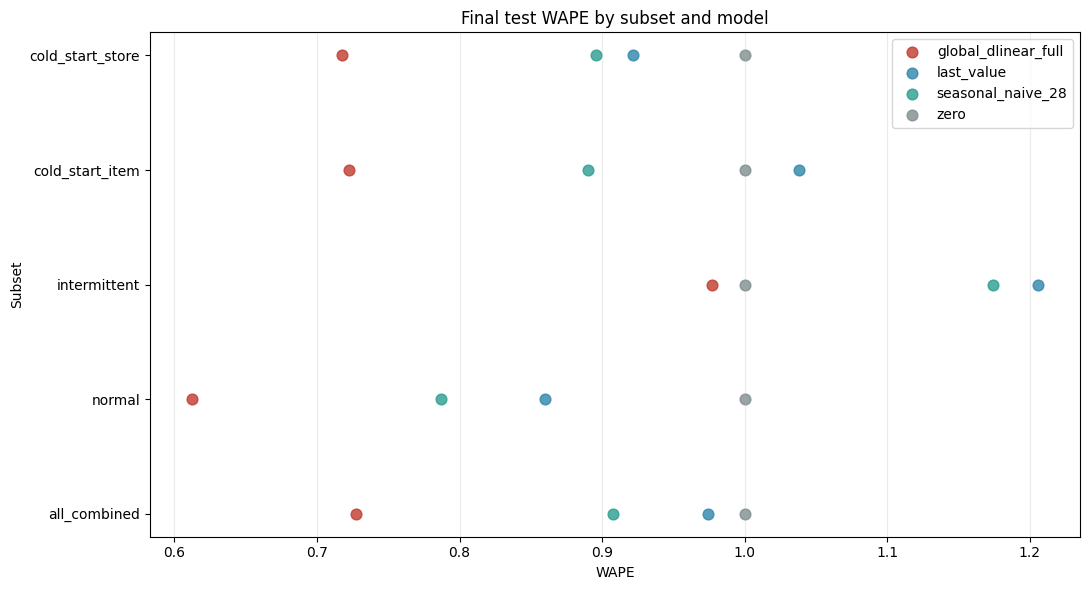

In [28]:
subsets_order = [
    "all_combined",
    "normal",
    "intermittent",
    "cold_start_item",
    "cold_start_store",
]
model_colors = {
    "zero": "#7F8C8D",
    "last_value": "#2E86AB",
    "seasonal_naive_28": "#2A9D8F",
    MODEL_NAME: "#C0392B",
}

plot_df = comparison_summary.copy()
plot_df["subset_y"] = plot_df["subset"].map({
    subset: position
    for position, subset in enumerate(subsets_order)
})

plt.figure(figsize=(11, 6))

for model_name, model_data in plot_df.groupby("model_name"):
    plt.scatter(
        model_data["wape_mean"],
        model_data["subset_y"],
        label=model_name,
        color=model_colors.get(model_name),
        alpha=0.8,
        s=60,
    )

plt.yticks(
    ticks=range(len(subsets_order)),
    labels=subsets_order,
)
plt.xlabel("WAPE")
plt.ylabel("Subset")
plt.title("Final test WAPE by subset and model")
plt.grid(axis="x", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation